In [1]:
import torch
from torch.nn.functional import threshold

from models import ou_model, logistic_model, simulate, plot_traj_set

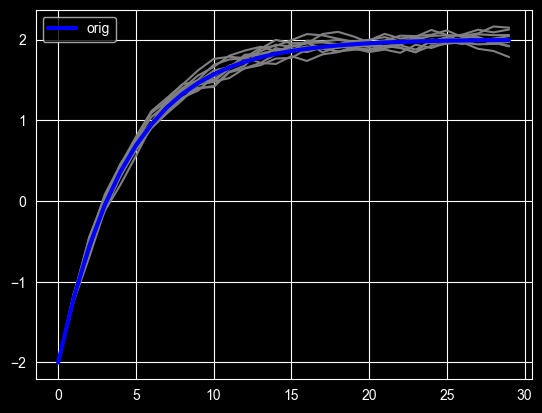

In [21]:
#ornstein uhlembeck process
# X_{t+1} = a*X_t + b + sigma*eps;  eps~normal(0,1)
time = 30
#fast convergence to x=2, with little noise
params = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.88,        #
            'b': 0.24,       #
            'sigma': 0.22}

#slower convergence to x=2, higher variance
params2 = {'time': time,      # time steps
            'init_x':4.,  # initial x
            'a': 0.96,        #
            'b': 0.08,       #
            'sigma': 0.18}


params3 = {'time': time,      # time steps
            'init_x':0.,  # initial x
            'a': 0.9,        #
            'b': 0.0,       #
            'sigma': 0.4}

params4 = {'time': time,      # time steps
            'init_x':-2.,  # initial x
            'a': 0.8,        #
            'b': 0.4,       #
            'sigma': 0.22}

trajs = simulate(ou_model, 10000, params4)

plot_traj_set(trajs, single_traj=10, color='blue', label='orig')

In [22]:
#globally |x| < threshold per set di parametri 3, th = 0.7
#eventually X > threshold per set di parametri 1, th = 2.1
threshold = 2.1
row_max = trajs.max(dim=1).values
#row_min = trajs.min(dim=1).values
tv = (row_max > threshold).int()
#tv = tv * (row_min > -threshold).int()
tv.float().mean()

tensor(0.3099, dtype=torch.float32)

In [4]:
col_mu = trajs.mean(dim=0)
col_mu[-1]

tensor(1.9933)

DeGAS section

In [14]:
# import module optimization to use DeGAS

from optimization import *
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)

In [41]:
# COMPILING AND SMOOTHING THE CFG

# Compile SOGA program to a smooth CFG
compiledFile = compile2SOGA('ou.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

# cfg represents now the smoothed program
# The cfg can be explored using the dictionary cfg.node_list

cfg.node_list

{'entry': EntryNode<>,
 'state0': StateNode<state0,None,X=-2.0,smoothed:X=-2.0+ gm([1.], [0.], [0.0010000000])>,
 'state1': StateNode<state1,None,phi=0,smoothed:phi=0+ gm([1.], [0.], [0.0010000000])>,
 'loop0': LoopNode<loop0>,
 'state2': StateNode<state2,True,X=0.8*X>,
 'state3': StateNode<state3,None,X=X+0.4+gm([1.0],[0.000000],[0.048400])>,
 'test0': TestNode<test0,X>2.1,smoothed:X > 2.1 + 0.1581138830>,
 'state4': StateNode<state4,True,phi=1,smoothed:phi=1+ gm([1.], [0.], [0.0010000000])>,
 'state5': StateNode<state5,False,skip>,
 'merge0': MergeNode<merge0>,
 'state6': StateNode<state6,None,skip>,
 'state7': StateNode<state7,False,skip>,
 'exit': ExitNode<>}

In [42]:
#run SOGA
output_dist = start_SOGA(cfg)

In [43]:
output_dist

Dist<['X', 'phi'],pi: tensor([[1.3278e-10],
        [7.3439e-10],
        [3.5472e-09],
        ...,
        [2.6018e-08],
        [1.0699e-09],
        [9.9639e-01]])
mu: tensor([[2.2932, 1.0000],
        [2.2932, 1.0000],
        [2.2932, 1.0000],
        ...,
        [2.0051, 1.0000],
        [2.0039, 1.0000],
        [1.9945, 0.0000]])
sigma: tensor([[[ 7.9288e-04,  0.0000e+00],
         [ 0.0000e+00,  1.0000e-06]],

        [[ 7.9285e-04,  0.0000e+00],
         [ 0.0000e+00,  1.0000e-06]],

        [[ 7.9278e-04,  0.0000e+00],
         [ 0.0000e+00,  1.0000e-06]],

        ...,

        [[ 6.3276e-03,  0.0000e+00],
         [-4.4409e-16,  1.0000e-06]],

        [[ 6.3402e-03,  0.0000e+00],
         [ 0.0000e+00,  1.0000e-06]],

        [[ 6.4098e-03,  0.0000e+00],
         [ 0.0000e+00,  1.0000e-06]]])>

In [44]:
#average value of phi
mu = output_dist.gm.mean()[1]
var = output_dist.gm.cov()[1,1]
print(mu,var)
print(output_dist.gm.mean())
print(output_dist.gm.cov())


tensor(0.0036) tensor(0.0036)
tensor([1.9950, 0.0036])
tensor([[0.0065, 0.0005],
        [0.0005, 0.0036]])


In [20]:
output_dist.gm.mean()[1]

tensor(0.0036)

In [65]:
torch.mean(output_dist.gm.sigma[:,1,1])
#output_dist.gm.mu[:,1]

tensor(1.0000e-06)

In [82]:
output_dist

Dist<['currX', 'phi', 'newX'],pi: tensor([[5.6349e-10],
        [1.9791e-08],
        [1.4614e-10],
        ...,
        [3.2754e-07],
        [3.4541e-09],
        [6.5812e-01]])
mu: tensor([[2.1567, 1.0000, 2.1567],
        [2.1567, 1.0000, 2.1567],
        [2.1567, 1.0000, 2.1567],
        ...,
        [1.9691, 1.0000, 1.9691],
        [1.9690, 1.0000, 1.9690],
        [1.9675, 0.0000, 1.9675]])
sigma: tensor([[[1.5741e-03, 0.0000e+00, 1.5731e-03],
         [0.0000e+00, 1.0000e-06, 0.0000e+00],
         [1.5731e-03, 0.0000e+00, 1.5731e-03]],

        [[1.5740e-03, 0.0000e+00, 1.5730e-03],
         [0.0000e+00, 1.0000e-06, 0.0000e+00],
         [1.5730e-03, 0.0000e+00, 1.5730e-03]],

        [[1.5740e-03, 0.0000e+00, 1.5730e-03],
         [0.0000e+00, 1.0000e-06, 0.0000e+00],
         [1.5730e-03, 0.0000e+00, 1.5730e-03]],

        ...,

        [[4.2088e-03, 2.2204e-16, 4.2078e-03],
         [2.2204e-16, 1.0000e-06, 2.2204e-16],
         [4.2078e-03, 2.2204e-16, 4.2078e-03]],

     